In [ ]:
#Importation des bibliothèques nécessaire 
from faker import Faker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode
import random
from datetime import datetime,timedelta
from scipy.cluster.vq import whiten, kmeans, vq

## **1. Création des profils d’utilisateurs, des films et de l'historique de visionnage**


In [2]:
#Importation de Faker pour les informations aléatoire
faker = Faker()

In [3]:
#Liste des genres
genres = [
    "Action", "Drame", "Comédie", "Science-Fiction",
    "Thriller", "Horreur", "Romance","Animé"
]

### **Génération des films**

In [4]:
#Liste des films
films = [
    # Science-Fiction
    {"movie": "Inception", "genre": "Science-Fiction", "director": "Christopher Nolan"},{"movie": "Interstellar", "genre": "Science-Fiction", "director": "Christopher Nolan"},{"movie": "The Matrix", "genre": "Science-Fiction", "director": "Lana Wachowski, Lilly Wachowski"},{"movie": "Arrival", "genre": "Science-Fiction", "director": "Denis Villeneuve"},{"movie": "Blade Runner 2049", "genre": "Science-Fiction", "director": "Denis Villeneuve"},{"movie": "Ex Machina", "genre": "Science-Fiction", "director": "Alex Garland"},

    # Action
    {"movie": "Gladiator", "genre": "Action", "director": "Ridley Scott"},{"movie": "The Dark Knight", "genre": "Action", "director": "Christopher Nolan"},{"movie": "Mad Max: Fury Road", "genre": "Action", "director": "George Miller"},{"movie": "Die Hard", "genre": "Action", "director": "John McTiernan"},{"movie": "John Wick", "genre": "Action", "director": "Chad Stahelski"},{"movie": "Mission Impossible: Fallout", "genre": "Action", "director": "Christopher McQuarrie"},

    # Drame
    {"movie": "Forrest Gump", "genre": "Drame", "director": "Robert Zemeckis"},{"movie": "Fight Club", "genre": "Drame", "director": "David Fincher"},{"movie": "Whiplash", "genre": "Drame", "director": "Damien Chazelle"},{"movie": "The Social Network", "genre": "Drame", "director": "David Fincher"},{"movie": "A Beautiful Mind", "genre": "Drame", "director": "Ron Howard"},{"movie": "The Pursuit of Happyness", "genre": "Drame", "director": "Gabriele Muccino"},

    # Crime
    {"movie": "The Godfather", "genre": "Crime", "director": "Francis Ford Coppola"},{"movie": "Goodfellas", "genre": "Crime", "director": "Martin Scorsese"},{"movie": "Pulp Fiction", "genre": "Crime", "director": "Quentin Tarantino"},{"movie": "The Departed", "genre": "Crime", "director": "Martin Scorsese"},{"movie": "Casino", "genre": "Crime", "director": "Martin Scorsese"},{"movie": "Heat", "genre": "Crime", "director": "Michael Mann"},

    # Thriller
    {"movie": "Se7en", "genre": "Thriller", "director": "David Fincher"},{"movie": "Gone Girl", "genre": "Thriller", "director": "David Fincher"},{"movie": "Prisoners", "genre": "Thriller", "director": "Denis Villeneuve"},{"movie": "Parasite", "genre": "Thriller", "director": "Bong Joon-ho"},{"movie": "Oldboy", "genre": "Thriller", "director": "Park Chan-wook"},{"movie": "Zodiac", "genre": "Thriller", "director": "David Fincher"},

    # Horreur
    {"movie": "The Conjuring", "genre": "Horreur", "director": "James Wan"},{"movie": "Get Out", "genre": "Horreur", "director": "Jordan Peele"},{"movie": "Hereditary", "genre": "Horreur", "director": "Ari Aster"},{"movie": "A Quiet Place", "genre": "Horreur", "director": "John Krasinski"},{"movie": "It", "genre": "Horreur", "director": "Andy Muschietti"},{"movie": "The Shining", "genre": "Horreur", "director": "Stanley Kubrick"},

    # Comédie
    {"movie": "Home Alone", "genre": "Comédie", "director": "Chris Columbus"},{"movie": "The Hangover", "genre": "Comédie", "director": "Todd Phillips"},{"movie": "Superbad", "genre": "Comédie", "director": "Greg Mottola"},{"movie": "The Grand Budapest Hotel", "genre": "Comédie", "director": "Wes Anderson"},{"movie": "Yes Man", "genre": "Comédie", "director": "Peyton Reed"},{"movie": "Bruce Almighty", "genre": "Comédie", "director": "Tom Shadyac"},

    # Romance
    {"movie": "Titanic", "genre": "Romance", "director": "James Cameron"},{"movie": "The Notebook", "genre": "Romance", "director": "Nick Cassavetes"},{"movie": "Pride and Prejudice", "genre": "Romance", "director": "Joe Wright"},{"movie": "Before Sunrise", "genre": "Romance", "director": "Richard Linklater"},{"movie": "La La Land", "genre": "Romance", "director": "Damien Chazelle"},{"movie": "A Star Is Born", "genre": "Romance", "director": "Bradley Cooper"},

    # Aventure
    {"movie": "Jurassic Park", "genre": "Aventure", "director": "Steven Spielberg"},{"movie": "Indiana Jones and the Last Crusade", "genre": "Aventure", "director": "Steven Spielberg"},{"movie": "Pirates of the Caribbean", "genre": "Aventure", "director": "Gore Verbinski"},{"movie": "The Revenant", "genre": "Aventure", "director": "Alejandro G. Inarritu"},{"movie": "The Lord of the Rings: The Fellowship of the Ring", "genre": "Aventure", "director": "Peter Jackson"},{"movie": "The Hobbit: An Unexpected Journey", "genre": "Aventure", "director": "Peter Jackson"},

    # Guerre / Historique
    {"movie": "Saving Private Ryan", "genre": "Guerre", "director": "Steven Spielberg"},{"movie": "1917", "genre": "Guerre", "director": "Sam Mendes"},{"movie": "Dunkirk", "genre": "Guerre", "director": "Christopher Nolan"},{"movie": "Schindler's List", "genre": "Historique", "director": "Steven Spielberg"},{"movie": "Oppenheimer", "genre": "Historique", "director": "Christopher Nolan"},{"movie": "The Imitation Game", "genre": "Historique", "director": "Morten Tyldum"},

    # Animation / Animé
    {"movie": "Spirited Away", "genre": "Animé", "director": "Hayao Miyazaki"},{"movie": "Your Name", "genre": "Animé", "director": "Makoto Shinkai"},{"movie": "Toy Story", "genre": "Animation", "director": "John Lasseter"},{"movie": "Inside Out", "genre": "Animation", "director": "Pete Docter"},{"movie": "Ratatouille", "genre": "Animation", "director": "Brad Bird"},{"movie": "WALL-E", "genre": "Animation", "director": "Andrew Stanton"}
]

### **Ajout d'attribut pour compléter la liste des films**

In [5]:
#Ajout de trois autres attributs (year, duration, rate)
for film in films:
    film["year"] = random.randint(1980, 2025)    
    film["duration"] = random.randint(80, 200) 
    film["rate"] = random.randint(1, 5)

In [6]:
#Date de visionnage aléatoire
start_date = datetime.now() - timedelta(days=730) #Début des visonnage : 730 jours en arrière (soit depuis 2 ans )

### **Création des profils utilisateurs avec Faker**

In [7]:
#Creation des utilisateurs
users = []
user_id = 0
history_id = 0
for us in range(200):
    age = random.randint(16,70)
    user_id += 1 
    history_id += 1

    preference = random.sample(genres,k=random.randint(1,3))

    history = []

    for film in random.sample(films, k=random.randint(1, 6)):
        random_days = random.randint(0, 730) #Jour aléatoire entre 0 pour ajourdhui et 730 avant
        date = (start_date + timedelta(days=random_days)).strftime("%Y-%m-%d")
        history.append({
            "history_id" :history_id,
            "user_id" : random.randint(1,200),
            "movie": film["movie"],
            "genre": film["genre"],
            "director": film["director"],
            "rating": random.randint(1, 5),
            "watch_date" : date
        })

    users.append({
        "user_id" : user_id,
        "name" : faker.name(),
        "age" : age,
        "country" : faker.country(),
        "email" : faker.email(),
        "password" : faker.password(),
        "preferences" : preference,
        "watch_history" : history
    })

In [8]:
users[0:2]

[{'user_id': 1,
  'name': 'Jay Miller',
  'age': 57,
  'country': 'Nigeria',
  'email': 'ashleycunningham@example.net',
  'password': 'lE1DZpIj^!',
  'preferences': ['Action'],
  'watch_history': [{'history_id': 1,
    'user_id': 59,
    'movie': 'Jurassic Park',
    'genre': 'Aventure',
    'director': 'Steven Spielberg',
    'rating': 5,
    'watch_date': '2025-04-28'}]},
 {'user_id': 2,
  'name': 'Amy Frazier',
  'age': 40,
  'country': 'Guyana',
  'email': 'rebekah33@example.net',
  'password': 'Rr5Oi*K@z!',
  'preferences': ['Drame'],
  'watch_history': [{'history_id': 2,
    'user_id': 150,
    'movie': 'Mission Impossible: Fallout',
    'genre': 'Action',
    'director': 'Christopher McQuarrie',
    'rating': 2,
    'watch_date': '2024-06-13'},
   {'history_id': 2,
    'user_id': 200,
    'movie': 'The Social Network',
    'genre': 'Drame',
    'director': 'David Fincher',
    'rating': 4,
    'watch_date': '2026-02-13'}]}]

### **Transformation des datasets en dataframes avec pandas**

In [9]:
df_users = pd.DataFrame(users)

In [10]:
df_users.head()

,user_id,name,age,country,email,password,preferences,watch_history
0,1,Jay Miller,57,Nigeria,ashleycunningham@example.net,lE1DZpIj^!,[Action],"[{'history_id': 1, 'user_id': 59, 'movie': 'Ju..."
1,2,Amy Frazier,40,Guyana,rebekah33@example.net,Rr5Oi*K@z!,[Drame],"[{'history_id': 2, 'user_id': 150, 'movie': 'M..."
2,3,Karen Yang,21,Oman,dalton13@example.com,518$Vtr(%),[Horreur],"[{'history_id': 3, 'user_id': 179, 'movie': 'T..."
3,4,Katherine Williams,57,Ghana,cesarryan@example.com,$#X1EMrCxS,"[Thriller, Science-Fiction, Romance]","[{'history_id': 4, 'user_id': 185, 'movie': 'I..."
4,5,Rick Mcdonald,68,Liechtenstein,susanjefferson@example.net,885EIUccj*,[Romance],"[{'history_id': 5, 'user_id': 32, 'movie': 'Ti..."


In [11]:
#Création de l'historique de l'utilsateur (issu du dataframe df_users)
new_history = []

for histories in df_users['watch_history']:
    for film in histories:
        new_history.append(film)

df_watch_history = pd.DataFrame(new_history)

In [12]:
df_watch_history.head()

,history_id,user_id,movie,genre,director,rating,watch_date
0,1,59,Jurassic Park,Aventure,Steven Spielberg,5,2025-04-28
1,2,150,Mission Impossible: Fallout,Action,Christopher McQuarrie,2,2024-06-13
2,2,200,The Social Network,Drame,David Fincher,4,2026-02-13
3,3,179,The Conjuring,Horreur,James Wan,2,2026-02-09
4,3,59,The Pursuit of Happyness,Drame,Gabriele Muccino,2,2024-08-23


In [13]:
#Dataframe des films
df_film = pd.DataFrame(films)

In [14]:
df_film.head()

,movie,genre,director,year,duration,rate
0,Inception,Science-Fiction,Christopher Nolan,2023,189,3
1,Interstellar,Science-Fiction,Christopher Nolan,2015,129,5
2,The Matrix,Science-Fiction,"Lana Wachowski, Lilly Wachowski",1992,157,3
3,Arrival,Science-Fiction,Denis Villeneuve,2003,122,5
4,Blade Runner 2049,Science-Fiction,Denis Villeneuve,2010,169,3


In [15]:
df_users.head()

,user_id,name,age,country,email,password,preferences,watch_history
0,1,Jay Miller,57,Nigeria,ashleycunningham@example.net,lE1DZpIj^!,[Action],"[{'history_id': 1, 'user_id': 59, 'movie': 'Ju..."
1,2,Amy Frazier,40,Guyana,rebekah33@example.net,Rr5Oi*K@z!,[Drame],"[{'history_id': 2, 'user_id': 150, 'movie': 'M..."
2,3,Karen Yang,21,Oman,dalton13@example.com,518$Vtr(%),[Horreur],"[{'history_id': 3, 'user_id': 179, 'movie': 'T..."
3,4,Katherine Williams,57,Ghana,cesarryan@example.com,$#X1EMrCxS,"[Thriller, Science-Fiction, Romance]","[{'history_id': 4, 'user_id': 185, 'movie': 'I..."
4,5,Rick Mcdonald,68,Liechtenstein,susanjefferson@example.net,885EIUccj*,[Romance],"[{'history_id': 5, 'user_id': 32, 'movie': 'Ti..."


### **Ajout de données manquante et de doublons**

In [16]:
#Ajout de donnée manquante pour les utilisateurs
for m in range(15) :
    ligne = random.randint(0,len(df_users))
    colonne = random.choice(df_users.columns[1:],) #user_id n'est pas inclu
    df_users.loc[ligne,colonne] = np.nan

In [17]:
#Ajout de donnée manquante pour watch_history
for m in range(10) :
    ligne = random.randint(0,len(df_watch_history))
    df_watch_history.loc[ligne,'rating'] = np.nan

### **Ajout des doublons**

In [18]:
#Doublons pour les utilisateurs
doublons_users = df_users.sample(10,random_state=42)
df_users = pd.concat([df_users,doublons_users],ignore_index=True)

In [19]:
# Doublons pour les films
doublons_films = df_film.sample(5,random_state=42)
df_film = pd.concat([df_film,doublons_films],ignore_index=True)

### **Data cleaning**

#### **Cleaning de users**

In [20]:
#Il y a déjà un Dataframe dédié au films déjà regarder, donc il n'est pas essentiel de garder cette colonne
df_users = df_users.drop('watch_history',axis = 1)

In [21]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      210 non-null    int64  
 1   name         209 non-null    object 
 2   age          206 non-null    float64
 3   country      206 non-null    object 
 4   email        208 non-null    object 
 5   password     210 non-null    object 
 6   preferences  208 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 11.6+ KB


In [22]:
df_users.isnull().sum()

user_id        0
name           1
age            4
country        4
email          2
password       0
preferences    2
dtype: int64

La colonne name compte 3 valeurs manquantes, age (5 valeurs maquantes), country (2), email (2), password (2), preferences (1)

In [23]:
df_users['age'] = df_users['age'].fillna(df_users['age'].median())

In [24]:
df_users.isnull().sum()

user_id        0
name           1
age            0
country        4
email          2
password       0
preferences    2
dtype: int64

In [25]:
df_users = df_users[df_users['preferences'].notnull()]
df_users = df_users[df_users['password'].notnull()]
df_users['name'] = df_users['name'].fillna('Non renseigné') 
df_users['country'] = df_users['country'].fillna('Non renseigné') 
df_users['email'] = df_users['email'].fillna('Non renseigné') 

In [26]:
df_users.isnull().sum()

user_id        0
name           0
age            0
country        0
email          0
password       0
preferences    0
dtype: int64

In [27]:
#Vérification de la présence de doublon
df_users[['user_id','name','age','country','email','password']].duplicated().sum()

np.int64(10)

In [28]:
#Supppression des doublons en gardant les colonnes de type list
df_users = df_users.drop_duplicates(subset=['user_id','name','age','country','email','password'])

#### **Cleaning watch_history**

In [29]:
df_watch_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   history_id  772 non-null    int64  
 1   user_id     772 non-null    int64  
 2   movie       772 non-null    object 
 3   genre       772 non-null    object 
 4   director    772 non-null    object 
 5   rating      762 non-null    float64
 6   watch_date  772 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 42.3+ KB


In [30]:
# Convertion de la colonne watch_date qui est de type objet en date
df_watch_history['watch_date'] = pd.to_datetime(df_watch_history['watch_date'])

In [31]:
#Feature engeneering
df_watch_history['year'] = df_watch_history['watch_date'].dt.year
df_watch_history['month'] = df_watch_history['watch_date'].dt.month

In [32]:
df_watch_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   history_id  772 non-null    int64         
 1   user_id     772 non-null    int64         
 2   movie       772 non-null    object        
 3   genre       772 non-null    object        
 4   director    772 non-null    object        
 5   rating      762 non-null    float64       
 6   watch_date  772 non-null    datetime64[ns]
 7   year        772 non-null    int32         
 8   month       772 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(3)
memory usage: 48.4+ KB


In [33]:
df_watch_history.duplicated().sum()

np.int64(0)

In [34]:
df_watch_history.isnull().sum()

history_id     0
user_id        0
movie          0
genre          0
director       0
rating        10
watch_date     0
year           0
month          0
dtype: int64

10 valeurs manquantes pour rating

In [35]:
df_watch_history['rating'] = df_watch_history['rating'].fillna(df_watch_history["rating"].mean())

In [36]:
df_watch_history.isnull().sum()

history_id    0
user_id       0
movie         0
genre         0
director      0
rating        0
watch_date    0
year          0
month         0
dtype: int64

#### **Cleaning films**

In [37]:
df_film.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie     71 non-null     object
 1   genre     71 non-null     object
 2   director  71 non-null     object
 3   year      71 non-null     int64 
 4   duration  71 non-null     int64 
 5   rate      71 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 3.5+ KB


In [38]:
df_film.isnull().sum()

movie       0
genre       0
director    0
year        0
duration    0
rate        0
dtype: int64

Aucune valeur manquante

In [39]:
df_film.duplicated().sum()

np.int64(5)

In [40]:
df_film = df_film.drop_duplicates()

Et ainsi on fini de traiter nos données, on peut passer à leurs utilisations

## **2. Création du moteur de recommandation :**

### **2.1 Filtrer les films en fonction des préférences de l'utilisateur.**

In [41]:
preferences = df_users.loc[0, 'preferences']

In [42]:
preferences

['Action']

In [43]:
def preferences_films(preferences):
    films = df_film[df_film['genre'].isin(preferences)]
    return films

# Préférences du premier utilisateur
prefs = preferences

print("Films conseillés :")
all_pref = preferences_films(prefs)

for movie in all_pref['movie']:
    print(f"{movie}, ",end='')

Films conseillés :
Gladiator, The Dark Knight, Mad Max: Fury Road, Die Hard, John Wick, Mission Impossible: Fallout, 

On passe les préférences de l'utilisation à la fonction preferences_films, puis on récupère tous les films qui sont de ces genres et on affiche leurs titres à l'utilsateurs

### **2.2 Classement des films en fonction des notes des utilisateurs ou des similitudes de genre**

#### **Classement selon les notes des utilisateurs**

In [44]:
def ranking (df_film) :
    df_film_ranking = df_film.sort_values('rate',ascending=False)
    return df_film_ranking

df = ranking(df_film)
print('Voici la liste des films conseillé en fonction de la notation :')
for movie in df['movie']:
    print(f"{movie}, ",end='')

Voici la liste des films conseillé en fonction de la notation :
Interstellar, Arrival, Pirates of the Caribbean, Mission Impossible: Fallout, The Social Network, Get Out, Prisoners, Casino, Pulp Fiction, The Godfather, Titanic, 1917, Toy Story, The Imitation Game, Jurassic Park, Before Sunrise, Yes Man, Goodfellas, Forrest Gump, Gone Girl, The Conjuring, Ex Machina, The Revenant, Home Alone, The Shining, Bruce Almighty, A Beautiful Mind, Fight Club, Oldboy, Inception, The Matrix, A Quiet Place, Heat, Zodiac, It, A Star Is Born, WALL-E, Blade Runner 2049, The Hangover, Inside Out, Pride and Prejudice, Your Name, Mad Max: Fury Road, The Pursuit of Happyness, The Dark Knight, Indiana Jones and the Last Crusade, Superbad, La La Land, Dunkirk, Hereditary, Ratatouille, Spirited Away, Saving Private Ryan, The Departed, Die Hard, Gladiator, John Wick, Whiplash, Parasite, Se7en, The Notebook, The Grand Budapest Hotel, Schindler's List, The Hobbit: An Unexpected Journey, The Lord of the Rings: T

On affiche les films en fonction du rate

#### **Classement selon la similitude de genre**

In [45]:
def similarity(genre, preferences):
    if genre in preferences:
        return 1
    return 0

def ranking_similarity(df_film, preferences, top_n=10):
    df_film_similarity = df_film.copy()
    df_film_similarity['score_similarite'] = df_film_similarity['genre'].apply(
        lambda genre: similarity(genre, preferences)
    )
    df_film_similarity = df_film_similarity.sort_values(
        by=['score_similarite', 'rate', 'year'],
        ascending=[False, False, False]
    )

    return df_film_similarity.head(top_n)[
        ['movie', 'genre', 'rate', 'year', 'score_similarite']
    ]

df_similarity = ranking_similarity(df_film, prefs)

print('Préférences de l\'utilisateur :', prefs)
print('Voici le classement des films conseillés selon la similitude de genre :')
for movie in df_similarity['movie']:
    print(f"{movie}, ",end='')

Préférences de l'utilisateur : ['Action']
Voici le classement des films conseillés selon la similitude de genre :
Mission Impossible: Fallout, Mad Max: Fury Road, The Dark Knight, Gladiator, John Wick, Die Hard, The Imitation Game, Interstellar, Pirates of the Caribbean, Pulp Fiction, 

On passe les films et les préférence de l'utilisateur à la fonction ranking_similarity, puis on vérifie si le genre du film est présent dans les préférence du l'utilisateur, si c'est le cas on ajoute 1 pour dire que le film est similaire au préférence de l'utilisateur

**Exemple d'affichage**

In [46]:
user = df_users.loc[0]
user_see = df_watch_history[df_watch_history['user_id']==user['user_id']]

In [47]:
#Vu que les date sont généré de manière aléatoire (on organise et ça et on prend le nom film avec la dernière date)
last_see = user_see.sort_values('watch_date').iloc[-1]['movie']

In [48]:
suggestion =  df_similarity.iloc[0]['movie']

In [49]:
#Suggestion basé sur les similiarité
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion}')

Jay Miller, vous avez regarder A Quiet Place, peut-être que vous aimeriez Mission Impossible: Fallout


In [50]:
suggestion_note =  df.iloc[0]['movie']

In [51]:
#Suggestion basé sur les notes
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion_note}')

Jay Miller, vous avez regarder A Quiet Place, peut-être que vous aimeriez Interstellar


In [52]:
suggestion_all_pref =  all_pref.iloc[0]['movie']

In [53]:
#Suggestion basé sur la note
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion_note}')

Jay Miller, vous avez regarder A Quiet Place, peut-être que vous aimeriez Interstellar


### **Klustering K-Means avec Scipy**

On va transformer les goûts des utilisateurs en nombres afin que K-Means puisse les analyser.
On va en quelque grouper les aditionner les notes attribué aux films par les utilsateurs en fonction de chaque utilisateurs et de chaque catégorie de film

In [54]:
genre_user = []
for us in users:
    vec = []
    for genre in genres:

        score = 0
        for movie in us["watch_history"]:

            if movie["genre"] == genre:
                score += movie["rating"]
        vec.append(score)
    genre_user.append(vec)
                
df_genre = pd.DataFrame(
    genre_user,
    columns=genres
)

In [55]:
df_genre

,Action,Drame,Comédie,Science-Fiction,Thriller,Horreur,Romance,Animé
0,0,0,0,0,0,0,0,0
1,2,4,0,0,0,0,0,0
2,0,2,0,5,0,6,0,1
3,0,0,5,0,4,0,0,0
4,0,0,0,0,0,0,4,0
...,...,...,...,...,...,...,...,...
195,0,0,0,4,0,0,0,0
196,0,0,4,0,0,0,0,0
197,0,4,5,0,0,0,0,0
198,0,10,0,0,0,0,0,0


### **Normalisation**

Dans df_genre on voit que score varie entre les catégorie de film, le modèle peut souvent apprendre de la catégorie avec la meilleure note (la plus élévé comparé aux autres), whiten est plus utilisé avec k-means

In [56]:
X = whiten(df_genre)

In [57]:
X

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [1.0350094 , 2.12300947, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.06150474, 0.        , ..., 2.97295759, 0.        ,
        0.8320631 ],
       ...,
       [0.        , 2.12300947, 2.72772363, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 5.30752368, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.05928771,
        0.        ]], shape=(200, 8))

### **Clustering**

vq = Vector Quantization.

In [58]:
k = 3 #Création de 3 groupes d'utilisateur (par exemple grp 1 : Action, grp 2: romance, grp 3 : comédie)

centroids, distortion = kmeans(X, k) #distorsion mésure la qualité du clustering (plus cette valeur
                                     # est faibles, plus les utilisateurs sont proches de leur centre)

clusters, _ = vq(X, centroids) #On assigne chaque utilisateurs dans un groupe

df_genre["cluster"] = clusters #On ajoute chaque résultat au dataframe

In [59]:
df_genre['cluster'].unique()

array([0, 2, 1], dtype=int32)

On remarque qu'il y a trois catégorie d'utilisateurs

### **Recommandation par cluster**

Avant tout, on va créer un nouveau qui va contenir tout notre historique de film regarder par les utilisateur ainsi que leur note attribuer

In [60]:
ratings = []

for user_id, user in enumerate(users):

    for movie in user["watch_history"]:

        ratings.append({
            "user": user_id,
            "movie": movie["movie"],
            "rating": movie["rating"]
        })

df_rating = pd.DataFrame(ratings)

In [61]:
df_rating.head()

,user,movie,rating
0,0,Jurassic Park,5
1,1,Mission Impossible: Fallout,2
2,1,The Social Network,4
3,2,The Conjuring,2
4,2,The Pursuit of Happyness,2


In [62]:
df_rating["cluster"] = df_rating["user"].map(
    df_genre["cluster"]
)

def recommend_cluster_movies(user_id):

    cluster = df_genre.loc[user_id, "cluster"]

    movies = df_rating[
        df_rating["cluster"] == cluster
    ]

    recommendations = (
        movies.groupby("movie")["rating"]
        .mean()
        .sort_values(ascending=False)
    )

    return recommendations.head(5)
id_user = df_users.loc[0,'user_id']
movie_rec = recommend_cluster_movies(id_user)

In [63]:
#Suggestion basé sur le clustering
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {movie_rec.index[0]}')

Samantha Clark, vous avez regarder A Quiet Place, peut-être que vous aimeriez The Lord of the Rings: The Fellowship of the Ring


## **3. Analyse et visualisation des informations :**

In [64]:
user_watch_history = df_watch_history[df_watch_history['user_id'] == user['user_id']]

In [65]:
user_watch_history['genre'].value_counts()

genre
Drame              1
Science-Fiction    1
Thriller           1
Horreur            1
Animation          1
Romance            1
Name: count, dtype: int64

Historique de visionnage de l'utilisateur :


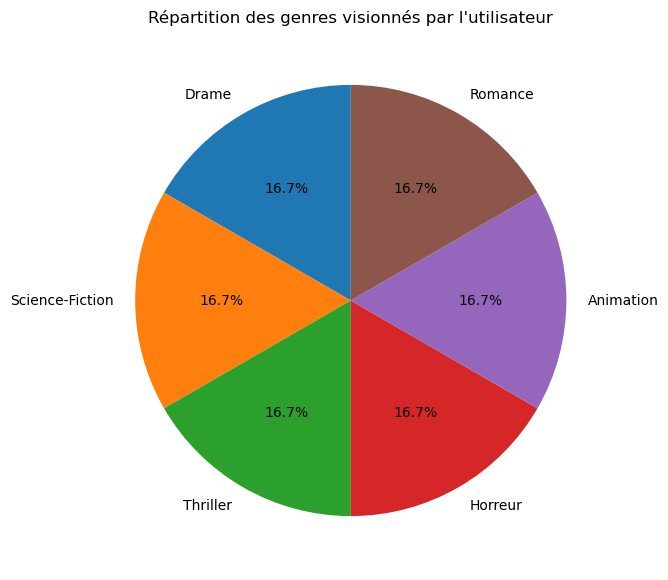

In [66]:
# Affichage de l'historique
print("Historique de visionnage de l'utilisateur :")

# 1. Répartition des genres

genre_counts = user_watch_history['genre'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des genres visionnés par l'utilisateur")
plt.show()

L'utilisateur regarde tout type de film

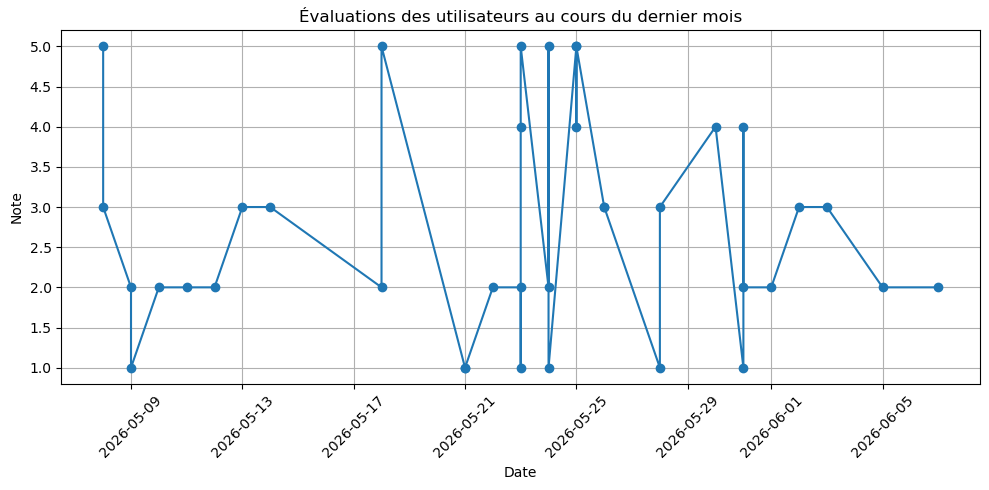

In [67]:
# Date la plus récente du dataset
last_date = df_watch_history['watch_date'].max()

# Données du dernier mois
last_month = df_watch_history[
    df_watch_history['watch_date'] >= last_date - pd.DateOffset(months=1)
]

# Tri par date
last_month = last_month.sort_values('watch_date')

plt.figure(figsize=(10, 5))

plt.plot(
    last_month['watch_date'],
    last_month['rating'],
    marker='o'
)

plt.title("Évaluations des utilisateurs au cours du dernier mois")
plt.xlabel("Date")
plt.ylabel("Note")
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Bonus** (Genre les mieux notées et mals notés)

In [68]:
df_watch_history[(df_watch_history['rating']>=4) & (df_watch_history['watch_date']>'2026-5-1')]['genre'].value_counts()

genre
Action             4
Thriller           2
Animation          2
Historique         1
Drame              1
Crime              1
Horreur            1
Romance            1
Science-Fiction    1
Name: count, dtype: int64

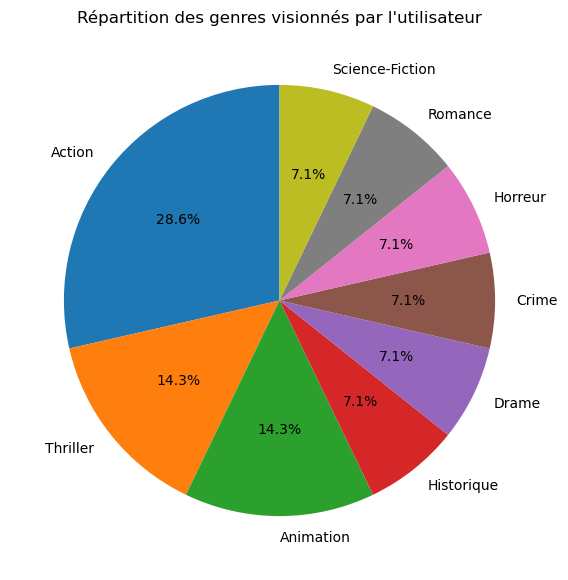

In [69]:
genre = df_watch_history[(df_watch_history['rating']>=4) & (df_watch_history['watch_date']>'2026-5-1')]['genre'].value_counts()
plt.figure(figsize=(7, 7))

plt.pie(
    genre,
    labels=genre.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des genres visionnés par l'utilisateur")
plt.show()

On constate que les notes des utilisateurs ne sont pas constante mais varie fortement, les utilsateurs on plus aimé les films d'action que les autres 

In [70]:
df_watch_history[(df_watch_history['rating']<=2) & (df_watch_history['watch_date']>'2026-5-1')]['genre'].value_counts()

genre
Action             4
Science-Fiction    3
Crime              3
Aventure           3
Horreur            2
Comédie            2
Thriller           2
Romance            1
Historique         1
Guerre             1
Name: count, dtype: int64

In [71]:
df_watch_history[(df_watch_history['rating']<=2) & (df_watch_history['watch_date']>'2026-5-1')]

,history_id,user_id,movie,genre,director,rating,watch_date,year,month
63,20,114,It,Horreur,Andy Muschietti,2.0,2026-05-31,2026,5
126,37,105,John Wick,Action,Chad Stahelski,2.0,2026-05-12,2026,5
131,38,167,Superbad,Comédie,Greg Mottola,2.0,2026-05-06,2026,5
160,45,147,Mission Impossible: Fallout,Action,Christopher McQuarrie,1.0,2026-05-23,2026,5
179,49,94,The Matrix,Science-Fiction,"Lana Wachowski, Lilly Wachowski",1.0,2026-05-21,2026,5
191,54,53,The Revenant,Aventure,Alejandro G. Inarritu,1.0,2026-05-24,2026,5
308,88,134,The Hobbit: An Unexpected Journey,Aventure,Peter Jackson,1.0,2026-05-31,2026,5
320,90,26,Before Sunrise,Romance,Richard Linklater,2.0,2026-05-10,2026,5
333,93,196,Oppenheimer,Historique,Christopher Nolan,1.0,2026-05-28,2026,5
357,101,4,Oldboy,Thriller,Park Chan-wook,2.0,2026-05-05,2026,5


Certains films d'actions n'ont pas été trop apprécié